Although we have acheived the 7 percent increase in the accuracy .But we can observer the accurarcy on triaining data. At the cell below .  The acc in training data is more than in test data. 
This is OVERFITTING . as we are performing not well in new data . 

There is 98 % acc in train data
There is just 89 % in test data


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [7]:
# Set random seeds for reproducibility
torch.manual_seed(42)

# Check for GPU availiability and set variable to store the gpu as device 

In [8]:
# check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"using device {device}")

using device cuda


In [9]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


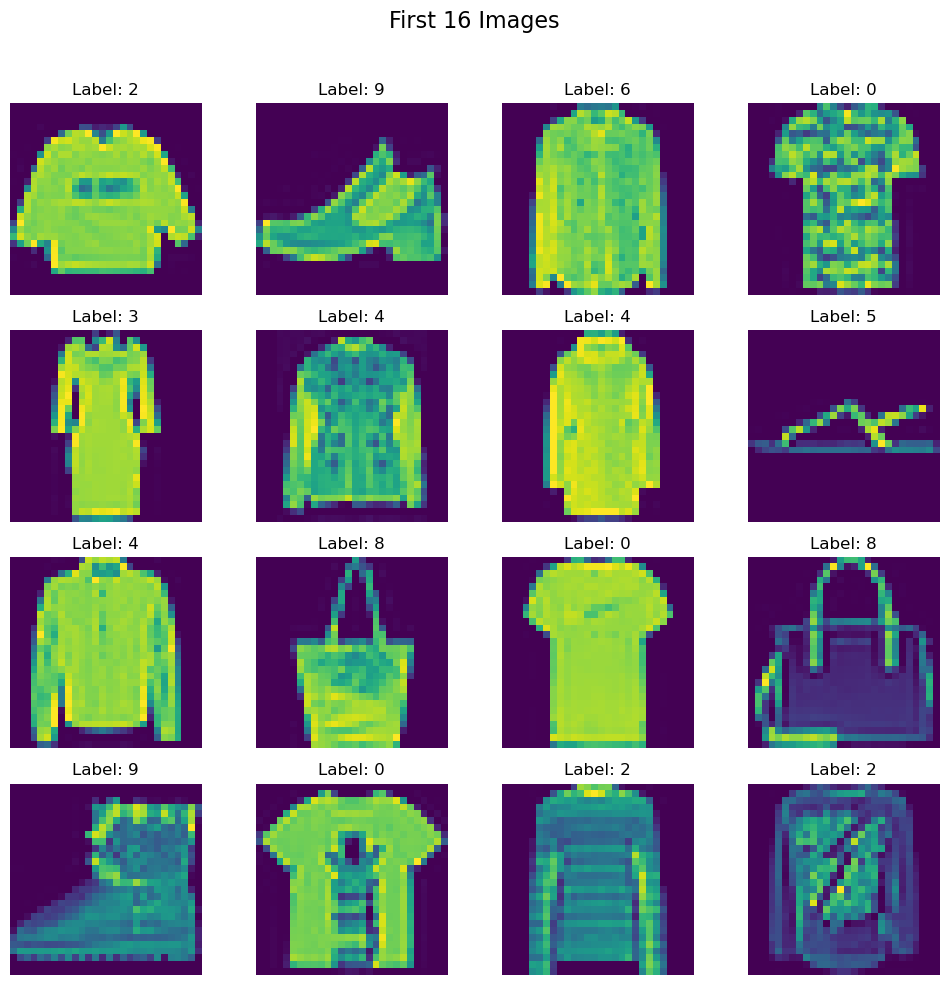

In [10]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [11]:
# train test split

X= df.iloc[:,1:].values
y= df.iloc[:,0].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]], shape=(48000, 784))

In [15]:
#create CustomeDataset class

class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [16]:
#create train_dataset object 

train_dataset=CustomDataset(X_train,y_train)


In [17]:
len(train_dataset)
# train_dataset[0]

48000

In [18]:
# create  test_dataset object 

test_dataset = CustomDataset(X_test,y_test)

In [19]:
len(test_dataset)

12000

# We can improve by batch_size to larger like 64, 128 as we have bigger data set . 

In [20]:
# create train and test loader 

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True , pin_memory=True) # this pin_memory is for speed on gpu. It store data in pin memory instread of first page memory to gpu memory

test_loader = DataLoader(test_dataset,batch_size=32, shuffle=False, pin_memory=True)

when creating the loader the data is saved in the memory . Then to the device memory. For cpu it is page memory and for GPU firstly RAM to the page memory -> pin_memory -> VRAM of the gpu . So the GPU will load data faster by removing the time of moving data to page then on pin  . This is very advantageous for big dataset where the VRAM cannot hold all data  

In [21]:
# define NN class

class FashionNN(nn.Module):

    def __init__(self,num_features):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
        # no need for last softmax activation function in pytorch

    def forward(self,X):

        return self.model(X)


In [22]:
# set learning rate and epochs 

epochs = 100
learning_rate = 0.1 


# Move model to the GPU . 

In [23]:
# instantiate the model 

model = FashionNN(X_train.shape[1])

# move model to device ie gpu
model.to(device)

# loss function

criterion = nn.CrossEntropyLoss()

# optimizer 
optimizer = optim.SGD(model.parameters(),lr=learning_rate)


In [24]:
len(train_loader)

1500

# Now for GPU we have to modify Training loop by moving our (data) i,e features and labels to the GPU device . 

In [25]:
# training loop 

for epoch in range(epochs):

    total_epoch_loss = 0
    for batch_features,batch_labels in train_loader:

        # Move data to gpu

        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)
        # calculate loss

        loss = criterion(outputs,batch_labels)

        #clear gradients
        optimizer.zero_grad()

        # back pass
        loss.backward()

        # update gradients 
        optimizer.step()

        total_epoch_loss += loss.item() 


    print(f"Epoch: {epoch +1 } ,AVG_loss :: {total_epoch_loss/len(train_loader)}")

Epoch: 1 ,AVG_loss :: 0.6351939847966035
Epoch: 2 ,AVG_loss :: 0.4295223894268274
Epoch: 3 ,AVG_loss :: 0.38697245326638224
Epoch: 4 ,AVG_loss :: 0.35851811634004116
Epoch: 5 ,AVG_loss :: 0.3374689698914687
Epoch: 6 ,AVG_loss :: 0.32276324506600695
Epoch: 7 ,AVG_loss :: 0.3091109267572562
Epoch: 8 ,AVG_loss :: 0.2960710582435131
Epoch: 9 ,AVG_loss :: 0.28609941966086627
Epoch: 10 ,AVG_loss :: 0.27487497349083423
Epoch: 11 ,AVG_loss :: 0.26887276383986075
Epoch: 12 ,AVG_loss :: 0.2602225929747025
Epoch: 13 ,AVG_loss :: 0.25162846118832627
Epoch: 14 ,AVG_loss :: 0.24446654767791431
Epoch: 15 ,AVG_loss :: 0.23874371533095837
Epoch: 16 ,AVG_loss :: 0.23296620321894684
Epoch: 17 ,AVG_loss :: 0.2270611963396271
Epoch: 18 ,AVG_loss :: 0.21988752119988203
Epoch: 19 ,AVG_loss :: 0.2151865517857174
Epoch: 20 ,AVG_loss :: 0.21058721568932137
Epoch: 21 ,AVG_loss :: 0.20601536283517877
Epoch: 22 ,AVG_loss :: 0.20027344976986447
Epoch: 23 ,AVG_loss :: 0.19468839794273177
Epoch: 24 ,AVG_loss :: 0.191

In [26]:
# set model to eval mode 

model.eval()

# this triggers the model to evaluation mode . It is useful when we use the dropouts, batch normalizations etc. 



FashionNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [27]:
len(test_loader)

375

In [28]:
# evaluation code 

total = 0

correct = 0

with torch.no_grad():

    for batch_features,batch_labels in train_loader:
        # there are 32 batches in test loader

        # Move data to gpu
        
        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        # here on trained model we are sending 1 batch of the data ie 32 images . so model will give us the output for each image out of 10 values which are probability of being 1 to 10 ). 
        # So tensor (32,10) will be given so for each row the maximum value(ie hihg prob) will decide which label will be predictions 

        _, predicted = torch.max(outputs,1) 

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

    print(correct/total)




0.9835833333333334


In [ ]:
# we can see it is 98 % accuracy. So it is overfitting. As there is almost 10 percent accuracy difference on the training and test data 

# Modify the Evaluation loop by Moving Data to GPU 

In [29]:
# evaluation code 

total = 0

correct = 0

with torch.no_grad():

    for batch_features,batch_labels in test_loader:
        # there are 32 batches in test loader

        # Move data to gpu
        
        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        # here on trained model we are sending 1 batch of the data ie 32 images . so model will give us the output for each image out of 10 values which are probability of being 1 to 10 ). 
        # So tensor (32,10) will be given so for each row the maximum value(ie hihg prob) will decide which label will be predictions 

        _, predicted = torch.max(outputs,1) 

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

    print(correct/total)




0.8901666666666667


# We can see we have achieve about 7 % of the improvement just by training on bigger data set .  

In [30]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

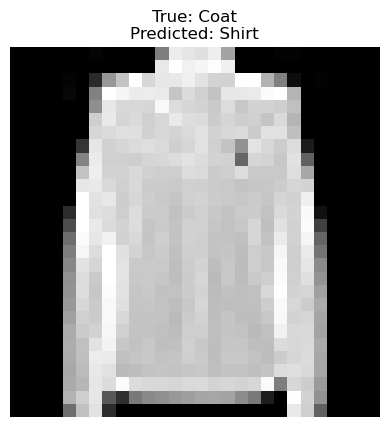

In [31]:
import random

# Random sample index
idx = random.randint(0, len(test_dataset)-1)

# Get image and label
image, true_label = test_dataset[idx]

# Add batch dimension
image_batch = image.unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(image_batch)
    _, predicted = torch.max(outputs, 1)

predicted_label = predicted.item()

# Display image
plt.imshow(image.view(28,28), cmap='gray')
plt.title(
    f"True: {classes[true_label]}\n"
    f"Predicted: {classes[predicted_label]}"
)
plt.axis("off")
plt.show()

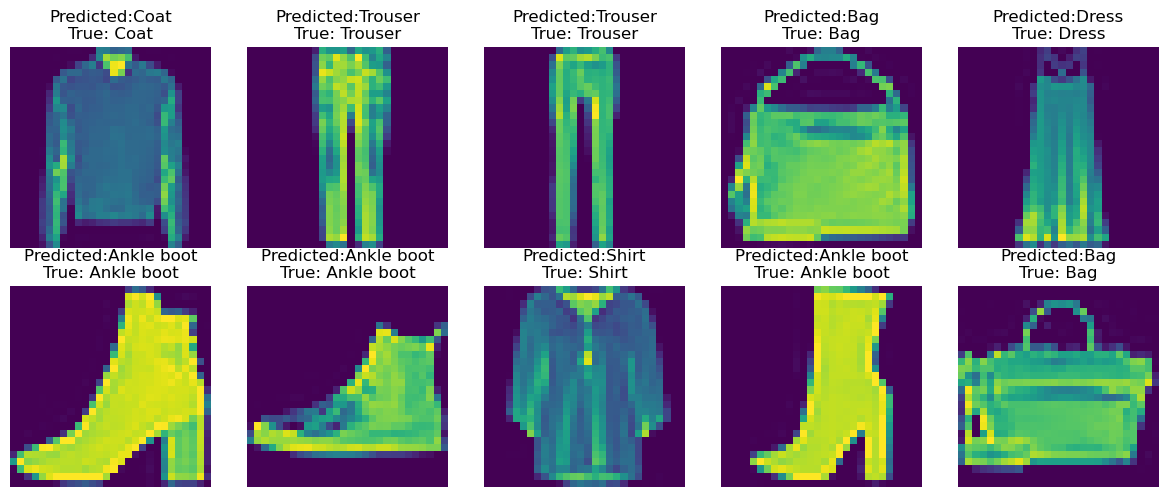

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

model.eval()

for ax in axes.flat:

    idx = random.randint(0, len(test_dataset)-1)

    image, label = test_dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()

    ax.imshow(image.view(28,28))
    ax.set_title(
        f"Predicted:{classes[pred]}\n"
        f"True: {classes[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()